# Positional Encoding Comparison
### Sinusoidal · Learned · RoPE · ALiBi

This notebook implements four major positional encoding strategies from scratch and visualizes how each one shapes attention patterns in a transformer.

| Method | Paper | Used in |
|---|---|---|
| **Sinusoidal** | Vaswani et al., 2017 | Original Transformer |
| **Learned** | Devlin et al., 2018 | BERT, GPT-2 |
| **RoPE** | Su et al., 2021 | LLaMA, Mistral, Gemma |
| **ALiBi** | Press et al., 2021 | BLOOM, MPT |

## 0. Imports & Configuration

In [1]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LinearSegmentedColormap
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
torch.manual_seed(42)
np.random.seed(42)

# ── Global config ─────────────────────────────────────────────────────────────
SEQ_LEN   = 32          # number of tokens
D_MODEL   = 64          # embedding dimension
N_HEADS   = 8           # attention heads
D_HEAD    = D_MODEL // N_HEADS   # 8
BATCH     = 1

# ── Colour palette ────────────────────────────────────────────────────────────
CMAP_ATTN = LinearSegmentedColormap.from_list(
    'attn', ['#042C53', '#185FA5', '#378ADD', '#B5D4F4', '#E6F1FB'], N=256)
CMAP_ENC  = 'RdBu_r'

plt.rcParams.update({
    'figure.dpi': 130,
    'font.family': 'DejaVu Sans',
    'axes.spines.top': False,
    'axes.spines.right': False,
})
print(f'Config ready — seq_len={SEQ_LEN}, d_model={D_MODEL}, n_heads={N_HEADS}')

Config ready — seq_len=32, d_model=64, n_heads=8


---
## 1. Sinusoidal Positional Encoding

The original encoding from *Attention Is All You Need*.

$$\text{PE}(pos, 2i)   = \sin\!\left(\frac{pos}{10000^{2i/d}}\right)$$
$$\text{PE}(pos, 2i+1) = \cos\!\left(\frac{pos}{10000^{2i/d}}\right)$$

**Key insight:** each dimension oscillates at a different frequency — lower dimensions change fast (fine position), higher dimensions change slowly (coarse position), like a binary number system.

In [2]:
class SinusoidalPE(nn.Module):
    """
    Classic sinusoidal positional encoding.
    No learnable parameters — fully deterministic.
    """
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)           # (L, D)
        pos = torch.arange(max_len).unsqueeze(1)     # (L, 1)
        # log-space computation for numerical stability
        div = torch.exp(
            torch.arange(0, d_model, 2) * (-np.log(10000.0) / d_model)
        )                                            # (D/2,)
        pe[:, 0::2] = torch.sin(pos * div)           # even dims
        pe[:, 1::2] = torch.cos(pos * div)           # odd  dims
        # register as buffer (not a parameter, but saved with model)
        self.register_buffer('pe', pe)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, L, D)  →  x + PE[:L]"""
        return x + self.pe[:x.size(1)]

    def get_matrix(self, seq_len: int) -> np.ndarray:
        """Return the raw PE matrix (L, D) as numpy."""
        return self.pe[:seq_len].cpu().numpy()


sine_pe = SinusoidalPE(D_MODEL)
sine_mat = sine_pe.get_matrix(SEQ_LEN)   # (32, 64)
print(f'Sinusoidal PE matrix shape: {sine_mat.shape}')
print(f'Value range: [{sine_mat.min():.3f}, {sine_mat.max():.3f}]')

Sinusoidal PE matrix shape: (32, 64)
Value range: [-1.000, 1.000]


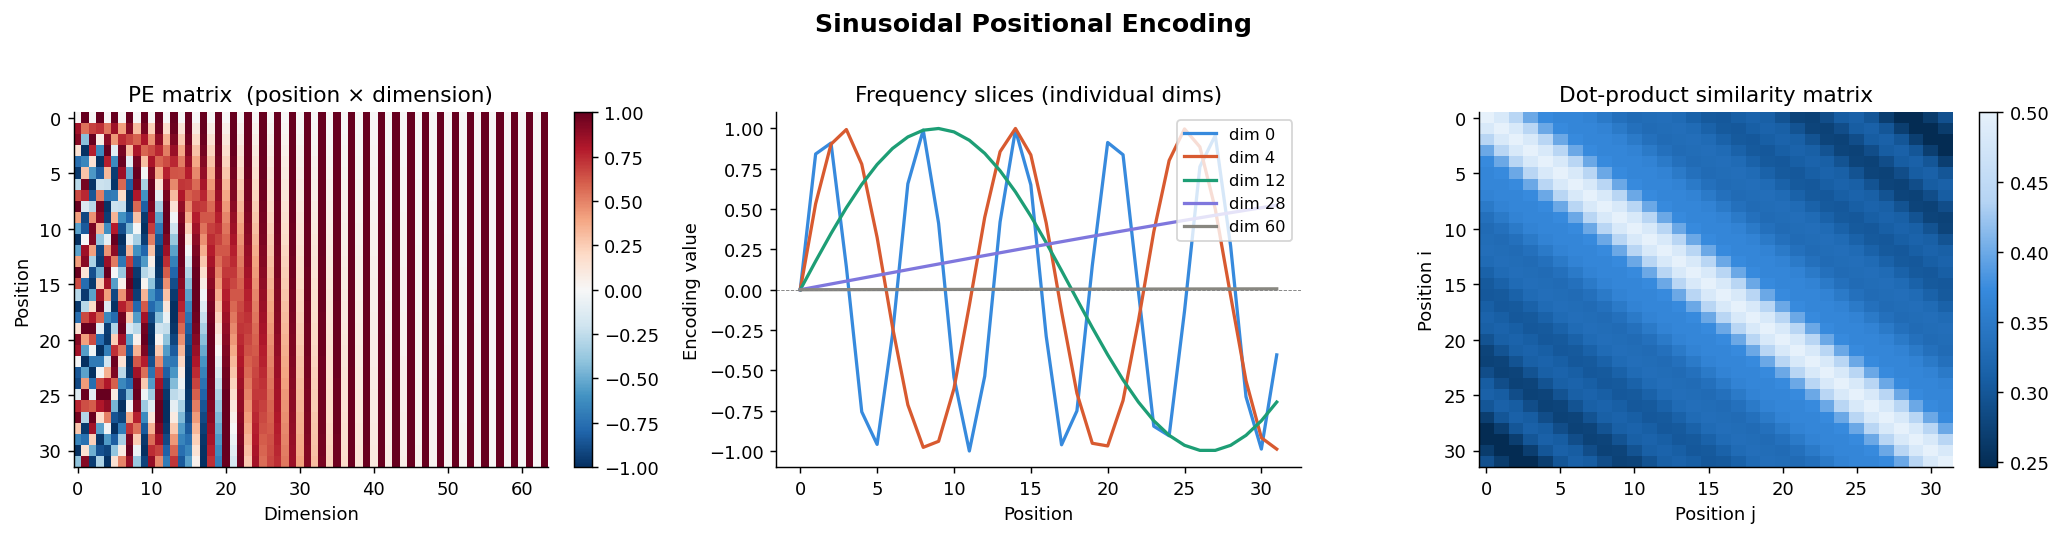

✓ Figure saved → sinusoidal_pe.png


In [3]:
# ── Visualise sinusoidal PE ───────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Sinusoidal Positional Encoding', fontsize=14, fontweight='bold', y=1.02)

# 1a — full heatmap
ax = axes[0]
im = ax.imshow(sine_mat, aspect='auto', cmap=CMAP_ENC, vmin=-1, vmax=1)
ax.set_title('PE matrix  (position × dimension)')
ax.set_xlabel('Dimension'); ax.set_ylabel('Position')
plt.colorbar(im, ax=ax, fraction=0.046)

# 1b — individual frequency slices
ax = axes[1]
dims_to_show = [0, 4, 12, 28, 60]
colors = ['#378ADD', '#D85A30', '#1D9E75', '#7F77DD', '#888780']
for d, c in zip(dims_to_show, colors):
    ax.plot(sine_mat[:, d], label=f'dim {d}', color=c, linewidth=1.8)
ax.set_title('Frequency slices (individual dims)')
ax.set_xlabel('Position'); ax.set_ylabel('Encoding value')
ax.legend(fontsize=9, loc='upper right')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# 1c — dot-product similarity between positions
ax = axes[2]
sim = sine_mat @ sine_mat.T       # (L, L)
sim /= D_MODEL                    # normalise
im2 = ax.imshow(sim, aspect='auto', cmap=CMAP_ATTN)
ax.set_title('Dot-product similarity matrix')
ax.set_xlabel('Position j'); ax.set_ylabel('Position i')
plt.colorbar(im2, ax=ax, fraction=0.046)

plt.tight_layout()
plt.savefig('sinusoidal_pe.png', bbox_inches='tight')
plt.show()
print('✓ Figure saved → sinusoidal_pe.png')

---
## 2. Learned Positional Embeddings

A trainable lookup table: `nn.Embedding(max_len, d_model)`.  
Each position index maps to an arbitrary vector learned from data.  
Used by **BERT** and **GPT-2**.

$$h = \text{TokenEmbed}(x) + \text{PosEmbed}(\text{pos\_idx})$$

**Trade-off:** highly task-adaptive, but **cannot generalize beyond** the maximum sequence length seen during training.

In [4]:
class LearnedPE(nn.Module):
    """
    Learnable position embedding table.
    Equivalent to nn.Embedding but named explicitly.
    """
    def __init__(self, d_model: int, max_len: int = 512):
        super().__init__()
        self.embed = nn.Embedding(max_len, d_model)
        # initialise close to sinusoidal to make the comparison fair
        nn.init.normal_(self.embed.weight, mean=0, std=0.02)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """x: (B, L, D)"""
        B, L, D = x.shape
        positions = torch.arange(L, device=x.device)   # (L,)
        return x + self.embed(positions)                # broadcast over batch

    def get_matrix(self, seq_len: int) -> np.ndarray:
        idx = torch.arange(seq_len)
        return self.embed(idx).detach().cpu().numpy()


learned_pe = LearnedPE(D_MODEL)
learned_mat = learned_pe.get_matrix(SEQ_LEN)   # (32, 64)

# ── Simulate what embeddings look like after some training (cosine annealing)
# We don't run full training here — instead we show the initialised state
# and the structural difference from sinusoidal.
print(f'Learned PE matrix shape : {learned_mat.shape}')
print(f'Parameter count         : {sum(p.numel() for p in learned_pe.parameters()):,}')

Learned PE matrix shape : (32, 64)
Parameter count         : 32,768


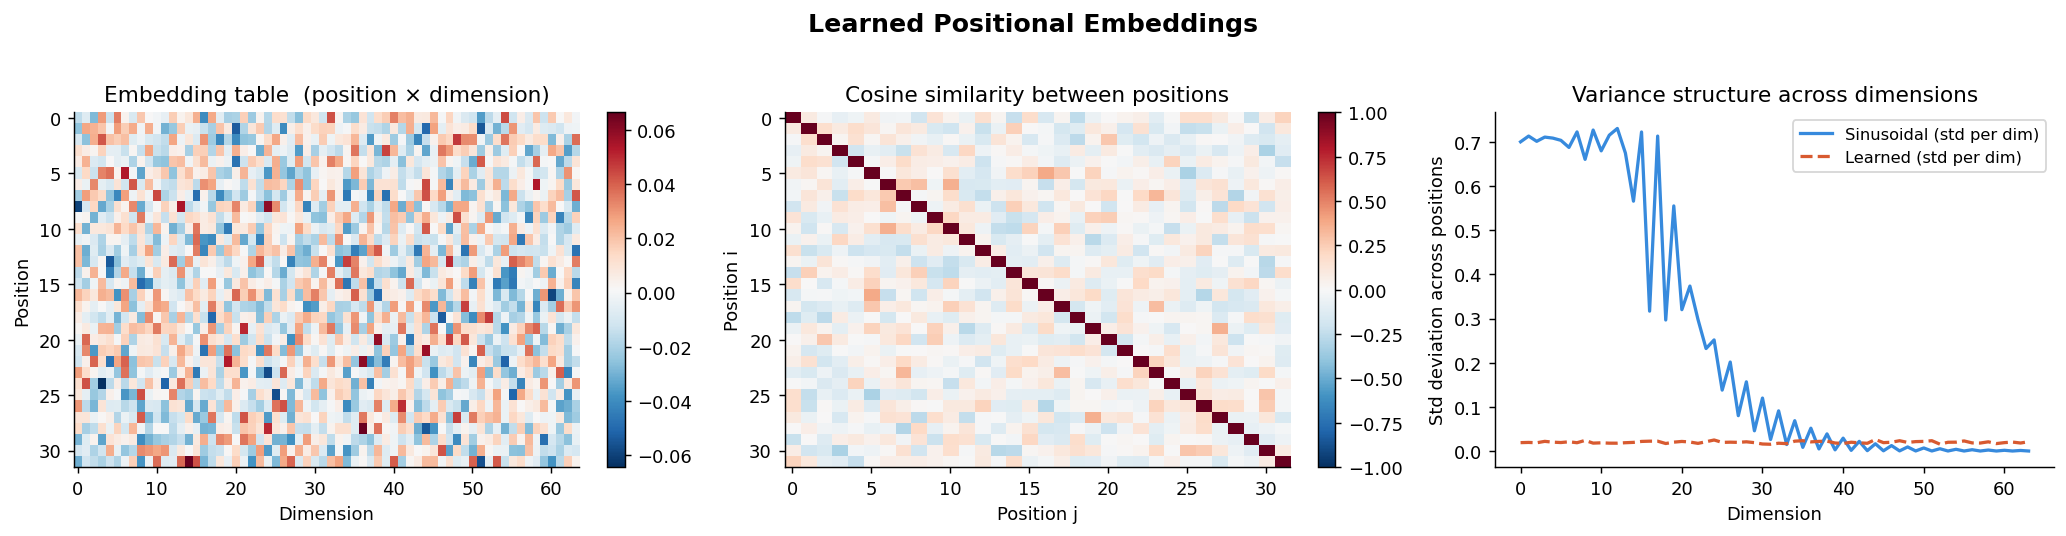

✓ Figure saved → learned_pe.png


In [5]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Learned Positional Embeddings', fontsize=14, fontweight='bold', y=1.02)

# 2a — embedding table heatmap
ax = axes[0]
im = ax.imshow(learned_mat, aspect='auto', cmap=CMAP_ENC)
ax.set_title('Embedding table  (position × dimension)')
ax.set_xlabel('Dimension'); ax.set_ylabel('Position')
plt.colorbar(im, ax=ax, fraction=0.046)

# 2b — cosine similarity between position vectors
ax = axes[1]
norms = np.linalg.norm(learned_mat, axis=1, keepdims=True)
normed = learned_mat / (norms + 1e-8)
cos_sim = normed @ normed.T
im2 = ax.imshow(cos_sim, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
ax.set_title('Cosine similarity between positions')
ax.set_xlabel('Position j'); ax.set_ylabel('Position i')
plt.colorbar(im2, ax=ax, fraction=0.046)

# 2c — comparison: sinusoidal vs learned structure
ax = axes[2]
ax.plot(np.std(sine_mat, axis=0),    label='Sinusoidal (std per dim)',
        color='#378ADD', linewidth=1.8)
ax.plot(np.std(learned_mat, axis=0), label='Learned (std per dim)',
        color='#D85A30', linewidth=1.8, linestyle='--')
ax.set_title('Variance structure across dimensions')
ax.set_xlabel('Dimension'); ax.set_ylabel('Std deviation across positions')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('learned_pe.png', bbox_inches='tight')
plt.show()
print('✓ Figure saved → learned_pe.png')

---
## 3. RoPE — Rotary Position Embedding

Su et al. (2021). Used in **LLaMA**, **Mistral**, **Qwen**, **Gemma**.

Instead of adding a vector, RoPE **rotates** Q and K vectors in 2D planes:

$$\mathbf{q}_m^\top \mathbf{k}_n = f(\mathbf{q}, m)^\top f(\mathbf{k}, n) = g(\mathbf{q}, \mathbf{k}, m-n)$$

The dot product depends **only on the relative distance** $m-n$, not absolute positions.

$$R_{\Theta,m} = \begin{pmatrix} \cos m\theta_1 & -\sin m\theta_1 & & \\ \sin m\theta_1 & \cos m\theta_1 & & \\ & & \ddots & \\ & & & \cos m\theta_{d/2} & -\sin m\theta_{d/2} \\ & & & \sin m\theta_{d/2} & \cos m\theta_{d/2} \end{pmatrix}$$

In [6]:
class RoPE(nn.Module):
    """
    Rotary Position Embedding (Su et al., 2021).
    Applied to Q and K separately before the dot-product.
    """
    def __init__(self, d_head: int, base: int = 10_000):
        super().__init__()
        # θ_i = 1 / base^(2i / d_head)   for i in [0, d_head/2)
        inv_freq = 1.0 / (
            base ** (torch.arange(0, d_head, 2).float() / d_head)
        )                                     # (d_head/2,)
        self.register_buffer('inv_freq', inv_freq)
        self.d_head = d_head

    def _get_sincos(self, seq_len: int, device):
        t   = torch.arange(seq_len, device=device).float()   # (L,)
        freqs = torch.outer(t, self.inv_freq)                 # (L, d/2)
        emb   = torch.cat([freqs, freqs], dim=-1)             # (L, d)
        return emb.cos(), emb.sin()

    @staticmethod
    def _rotate_half(x: torch.Tensor) -> torch.Tensor:
        """Rotate each 2D pair: [x1, x2] → [-x2, x1]"""
        x1 = x[..., : x.shape[-1] // 2]
        x2 = x[..., x.shape[-1] // 2 :]
        return torch.cat([-x2, x1], dim=-1)

    def apply_rotary(self, x: torch.Tensor, cos, sin) -> torch.Tensor:
        """x: (B, H, L, D_head)"""
        # cos/sin: (L, D_head) → broadcast over batch and heads
        cos = cos.unsqueeze(0).unsqueeze(0)   # (1, 1, L, D)
        sin = sin.unsqueeze(0).unsqueeze(0)
        return x * cos + self._rotate_half(x) * sin

    def forward(self, q: torch.Tensor, k: torch.Tensor):
        """
        q, k: (B, H, L, D_head)
        Returns rotated (q, k).
        """
        seq_len = q.size(2)
        cos, sin = self._get_sincos(seq_len, q.device)
        return self.apply_rotary(q, cos, sin), self.apply_rotary(k, cos, sin)

    def get_rotation_matrix(self, seq_len: int) -> np.ndarray:
        """Returns cos(m*theta) for each (pos, dim_pair) — visualisation helper."""
        t = torch.arange(seq_len).float()
        freqs = torch.outer(t, self.inv_freq)   # (L, d/2)
        return freqs.cos().numpy()


rope = RoPE(D_HEAD)
rot_mat = rope.get_rotation_matrix(SEQ_LEN)
print(f'RoPE rotation matrix shape : {rot_mat.shape}  (position × freq_pair)')

RoPE rotation matrix shape : (32, 4)  (position × freq_pair)


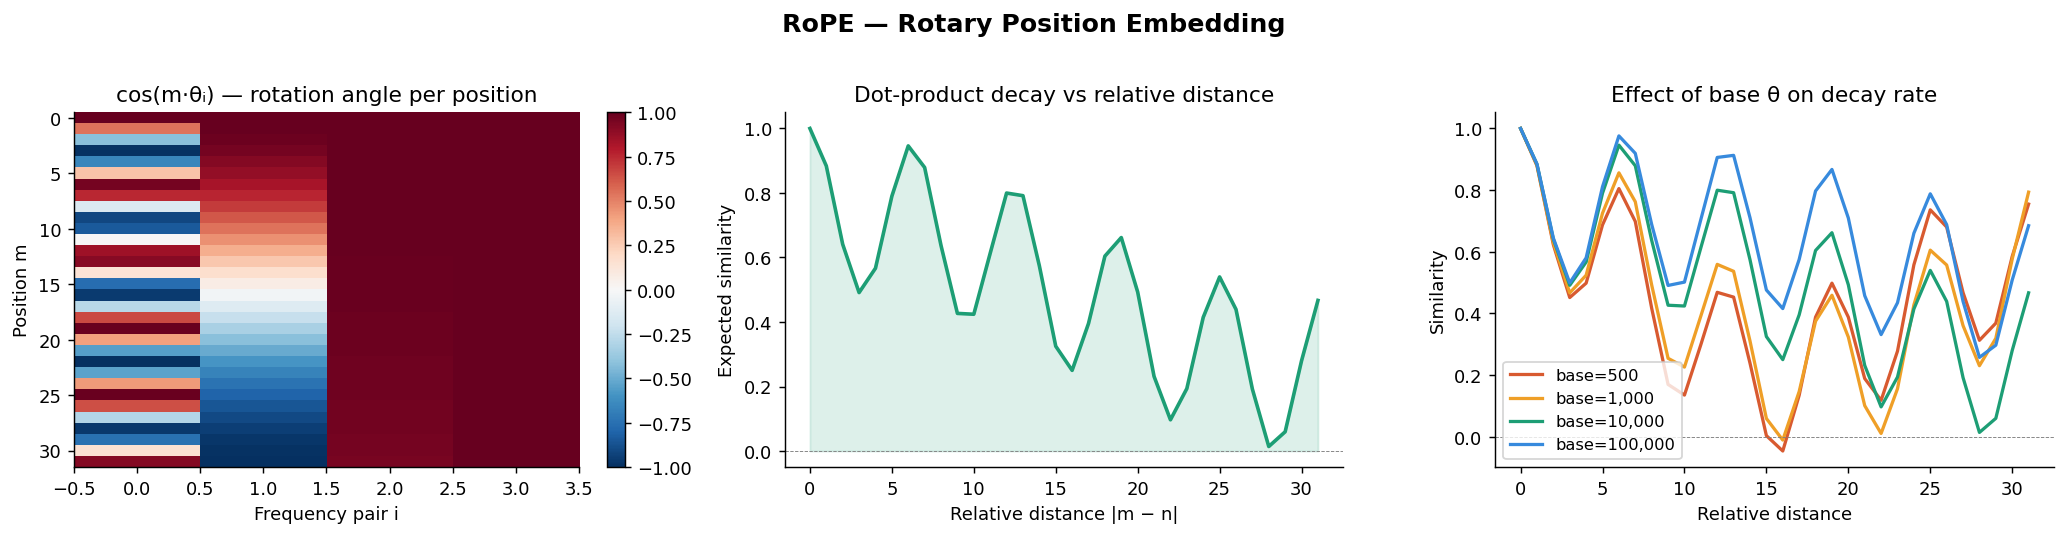

✓ Figure saved → rope_pe.png


In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('RoPE — Rotary Position Embedding', fontsize=14, fontweight='bold', y=1.02)

# 3a — rotation angle heatmap
ax = axes[0]
im = ax.imshow(rot_mat, aspect='auto', cmap=CMAP_ENC, vmin=-1, vmax=1)
ax.set_title('cos(m·θᵢ) — rotation angle per position')
ax.set_xlabel('Frequency pair i'); ax.set_ylabel('Position m')
plt.colorbar(im, ax=ax, fraction=0.046)

# 3b — relative distance decay
ax = axes[1]
# compute theoretical decay: E[cos((m-n)·θ)] averaged over freq pairs
dists = np.arange(SEQ_LEN)
inv_freq_np = rope.inv_freq.numpy()
decay = np.array([
    np.mean(np.cos(d * inv_freq_np)) for d in dists
])
ax.plot(dists, decay, color='#1D9E75', linewidth=2)
ax.fill_between(dists, decay, alpha=0.15, color='#1D9E75')
ax.set_title('Dot-product decay vs relative distance')
ax.set_xlabel('Relative distance |m − n|')
ax.set_ylabel('Expected similarity')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# 3c — compare decay for different base values
ax = axes[2]
for base, color in [(500, '#D85A30'), (1000, '#EF9F27'),
                    (10000, '#1D9E75'), (100000, '#378ADD')]:
    inv_f = 1.0 / (base ** (np.arange(0, D_HEAD, 2) / D_HEAD))
    d = np.array([np.mean(np.cos(dist * inv_f)) for dist in dists])
    ax.plot(dists, d, label=f'base={base:,}', color=color, linewidth=1.8)
ax.set_title('Effect of base θ on decay rate')
ax.set_xlabel('Relative distance'); ax.set_ylabel('Similarity')
ax.legend(fontsize=9)
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig('rope_pe.png', bbox_inches='tight')
plt.show()
print('✓ Figure saved → rope_pe.png')

---
## 4. ALiBi — Attention with Linear Biases

Press et al. (2021). Used in **BLOOM**, **MPT**.

No positional embeddings at all — instead a fixed linear penalty is subtracted from attention logits:

$$\text{Attn}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d}} - m \cdot |i - j|\right) V$$

Each head $h$ uses a different slope $m_h$ from a geometric series: $m_h = 2^{-8h/n}$.

**Key advantage:** since the bias is additive on logits, it generalises to any length without modification.

In [8]:
class ALiBi(nn.Module):
    """
    ALiBi positional bias (Press et al., 2021).
    Adds -m * |i-j| to raw attention logits before softmax.
    No learnable parameters.
    """
    def __init__(self, n_heads: int):
        super().__init__()
        self.n_heads = n_heads
        slopes = self._get_slopes(n_heads)               # (H,)
        self.register_buffer('slopes', slopes)

    @staticmethod
    def _get_slopes(n: int) -> torch.Tensor:
        """
        Geometric series of slopes: m_h = 2^(-8h/n)
        This ensures each head specialises in a different distance range.
        """
        def get_slopes_power_of_2(n):
            start = 2 ** (-(2 ** -(np.log2(n) - 3)))
            return [start * start ** i for i in range(n)]

        if np.log2(n) == int(np.log2(n)):    # power of 2
            slopes = get_slopes_power_of_2(n)
        else:
            # interpolate for non-power-of-2 head counts
            closest_pw2 = 2 ** int(np.log2(n))
            slopes = (
                get_slopes_power_of_2(closest_pw2) +
                get_slopes_power_of_2(2 * closest_pw2)[0::2][:n - closest_pw2]
            )
        return torch.tensor(slopes, dtype=torch.float32)

    def get_bias(self, seq_len: int, device=None) -> torch.Tensor:
        """
        Returns bias tensor of shape (H, L, L).
        bias[h, i, j] = -slopes[h] * |i - j|
        """
        pos   = torch.arange(seq_len, device=device)
        dist  = (pos.unsqueeze(0) - pos.unsqueeze(1)).abs().float()  # (L, L)
        bias  = -self.slopes.view(-1, 1, 1) * dist.unsqueeze(0)      # (H, L, L)
        return bias

    def forward(self, attn_logits: torch.Tensor) -> torch.Tensor:
        """
        attn_logits: (B, H, L, L)  → add ALiBi bias in-place
        """
        seq_len = attn_logits.size(-1)
        bias = self.get_bias(seq_len, attn_logits.device)   # (H, L, L)
        return attn_logits + bias.unsqueeze(0)              # broadcast over batch


alibi = ALiBi(N_HEADS)
alibi_bias = alibi.get_bias(SEQ_LEN).numpy()   # (H, L, L)
slopes_np  = alibi.slopes.numpy()

print(f'ALiBi bias shape: {alibi_bias.shape}')
print(f'Slopes: {np.round(slopes_np, 4)}')

ALiBi bias shape: (8, 32, 32)
Slopes: [0.5    0.25   0.125  0.0625 0.0312 0.0156 0.0078 0.0039]


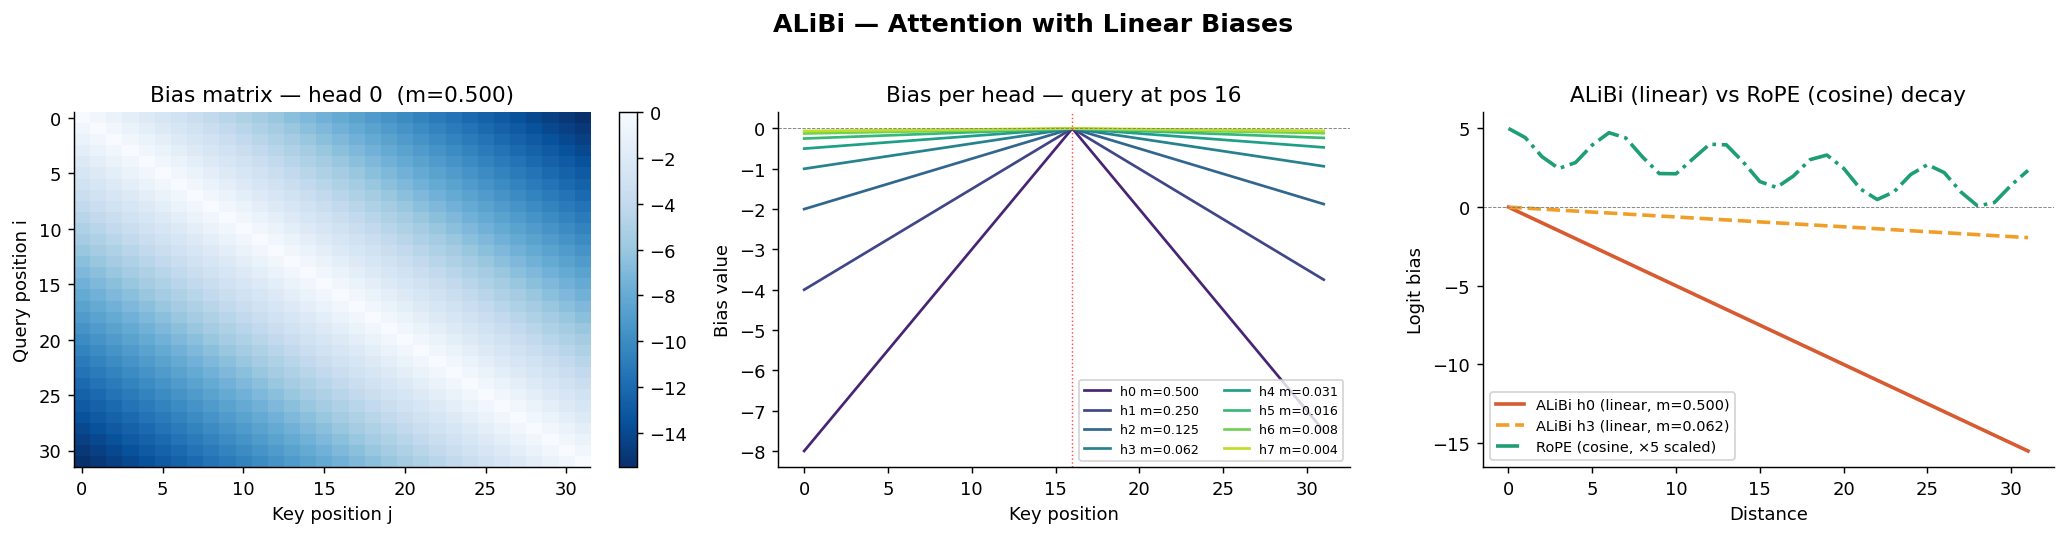

✓ Figure saved → alibi_pe.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('ALiBi — Attention with Linear Biases', fontsize=14, fontweight='bold', y=1.02)

# 4a — bias matrix for head 0
ax = axes[0]
im = ax.imshow(alibi_bias[0], aspect='auto', cmap='Blues_r')
ax.set_title(f'Bias matrix — head 0  (m={slopes_np[0]:.3f})')
ax.set_xlabel('Key position j'); ax.set_ylabel('Query position i')
plt.colorbar(im, ax=ax, fraction=0.046)

# 4b — all 8 heads' bias for query token 16
ax = axes[1]
query_pos = SEQ_LEN // 2
key_pos   = np.arange(SEQ_LEN)
colors = plt.cm.viridis(np.linspace(0.1, 0.9, N_HEADS))
for h in range(N_HEADS):
    ax.plot(key_pos, alibi_bias[h, query_pos], label=f'h{h} m={slopes_np[h]:.3f}',
            color=colors[h], linewidth=1.5)
ax.set_title(f'Bias per head — query at pos {query_pos}')
ax.set_xlabel('Key position'); ax.set_ylabel('Bias value')
ax.legend(fontsize=7, ncol=2, loc='lower right')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.axvline(query_pos, color='red', linewidth=0.8, linestyle=':', alpha=0.7)

# 4c — decay comparison: linear (ALiBi) vs cosine (RoPE)
ax = axes[2]
dists = np.arange(SEQ_LEN)
# ALiBi head 0 decay
ax.plot(dists, -slopes_np[0] * dists, color='#D85A30', linewidth=2,
        label=f'ALiBi h0 (linear, m={slopes_np[0]:.3f})')
ax.plot(dists, -slopes_np[3] * dists, color='#EF9F27', linewidth=2, linestyle='--',
        label=f'ALiBi h3 (linear, m={slopes_np[3]:.3f})')
# RoPE decay
inv_f = rope.inv_freq.numpy()
rope_decay = np.array([np.mean(np.cos(d * inv_f)) for d in dists])
ax.plot(dists, rope_decay * 5, color='#1D9E75', linewidth=2, linestyle='-.',
        label='RoPE (cosine, ×5 scaled)')
ax.set_title('ALiBi (linear) vs RoPE (cosine) decay')
ax.set_xlabel('Distance'); ax.set_ylabel('Logit bias')
ax.legend(fontsize=8); ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

plt.tight_layout()
plt.savefig('alibi_pe.png', bbox_inches='tight')
plt.show()
print('✓ Figure saved → alibi_pe.png')

---
## 5. Attention Pattern Comparison

We build a minimal single-head attention layer and run all four encodings through it to compare resulting attention maps.

In [10]:
class MinimalAttention(nn.Module):
    """
    Single-head scaled dot-product attention, causal mask optional.
    Accepts an optional pre-softmax bias (for ALiBi).
    """
    def __init__(self, d_model: int):
        super().__init__()
        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.scale = d_model ** -0.5

    def forward(self, x: torch.Tensor, bias=None, causal: bool = True):
        """
        x   : (B, L, D)
        bias: (B or 1, 1 or H, L, L) additive logit bias (for ALiBi)
        Returns (output, attention_weights)
        """
        B, L, D = x.shape
        q = self.W_q(x)   # (B, L, D)
        k = self.W_k(x)
        v = self.W_v(x)

        # scaled dot-product
        attn = torch.bmm(q, k.transpose(1, 2)) * self.scale   # (B, L, L)

        if bias is not None:
            attn = attn + bias

        if causal:
            mask = torch.tril(torch.ones(L, L, device=x.device)).bool()
            attn = attn.masked_fill(~mask, float('-inf'))

        weights = F.softmax(attn, dim=-1)   # (B, L, L)
        out = torch.bmm(weights, v)
        return out, weights


# ── Shared input: random token embeddings ─────────────────────────────────────
torch.manual_seed(42)
x_raw = torch.randn(BATCH, SEQ_LEN, D_MODEL)   # (1, 32, 64)
attn_layer = MinimalAttention(D_MODEL)


def get_attn_weights(encoding: str) -> np.ndarray:
    """Return (L, L) attention weight matrix for the given encoding."""
    with torch.no_grad():
        if encoding == 'sinusoidal':
            x = sine_pe(x_raw)
            _, w = attn_layer(x)

        elif encoding == 'learned':
            x = learned_pe(x_raw)
            _, w = attn_layer(x)

        elif encoding == 'rope':
            # RoPE is applied to Q/K inside attention — we approximate with
            # a single head for simplicity (full multi-head in next section)
            q = attn_layer.W_q(x_raw)       # (B, L, D)
            k = attn_layer.W_k(x_raw)
            v = attn_layer.W_v(x_raw)
            # reshape to (B, H=1, L, D)
            q_h = q.unsqueeze(1); k_h = k.unsqueeze(1)
            rope_full = RoPE(D_MODEL)
            q_r, k_r = rope_full(q_h, k_h)
            q_r = q_r.squeeze(1); k_r = k_r.squeeze(1)
            scale = D_MODEL ** -0.5
            attn_s = torch.bmm(q_r, k_r.transpose(1, 2)) * scale
            mask = torch.tril(torch.ones(SEQ_LEN, SEQ_LEN)).bool()
            attn_s = attn_s.masked_fill(~mask, float('-inf'))
            w = F.softmax(attn_s, dim=-1)

        elif encoding == 'alibi':
            alibi_bias_t = alibi.get_bias(SEQ_LEN)   # (H, L, L)
            # use head 0 bias for single-head comparison
            bias_0 = alibi_bias_t[0].unsqueeze(0)    # (1, L, L)
            _, w = attn_layer(x_raw, bias=bias_0)

    return w[0].numpy()   # (L, L)


weights = {
    'sinusoidal': get_attn_weights('sinusoidal'),
    'learned'   : get_attn_weights('learned'),
    'rope'      : get_attn_weights('rope'),
    'alibi'     : get_attn_weights('alibi'),
}
print('Attention weights computed for all four encodings.')

Attention weights computed for all four encodings.


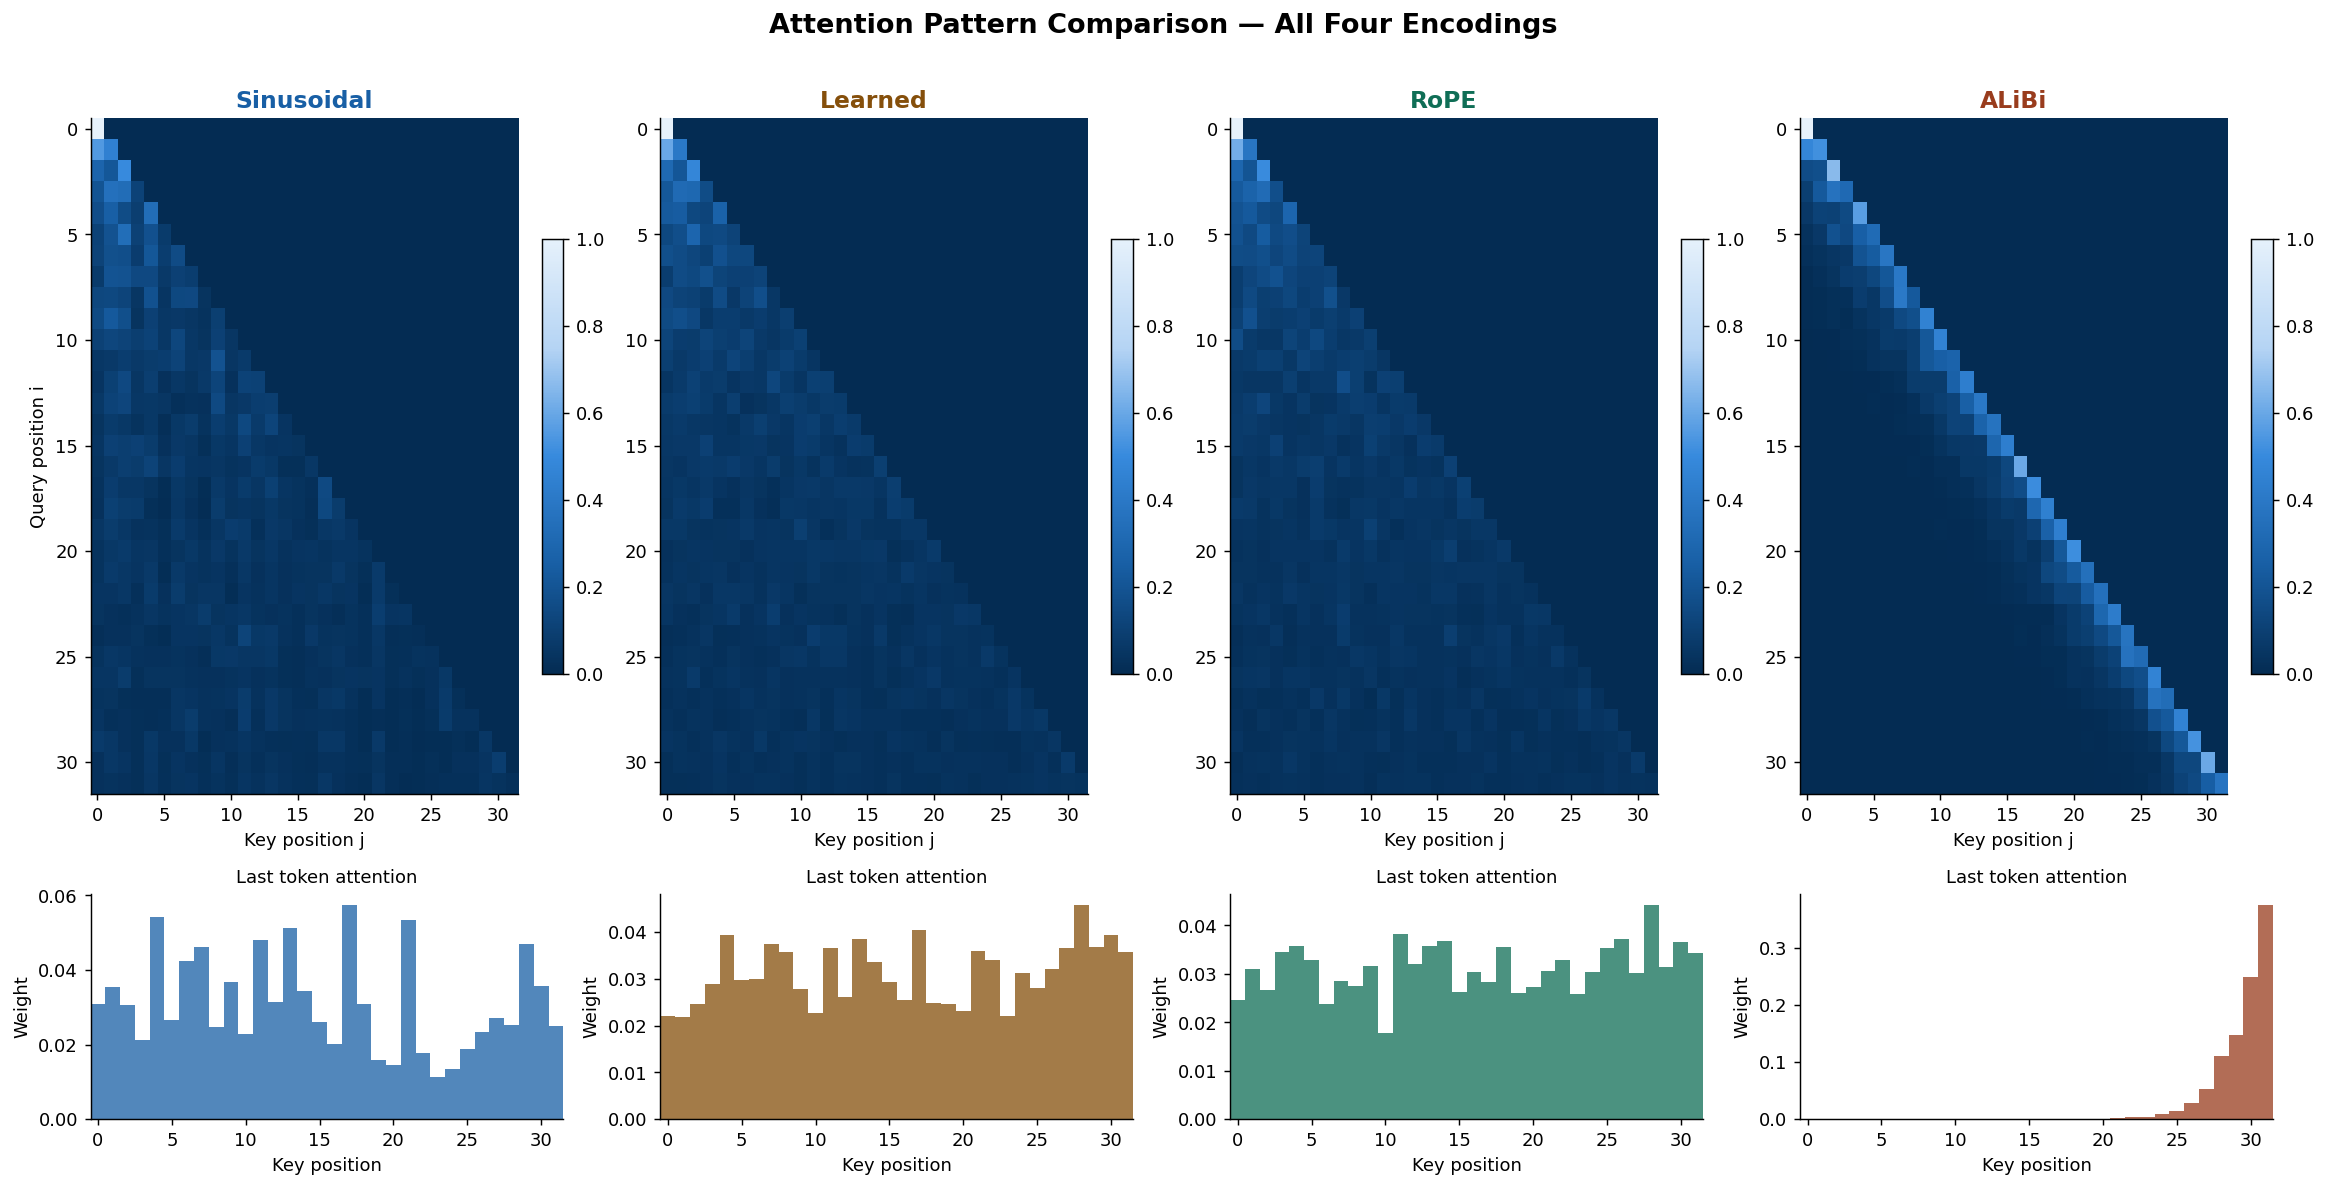

✓ Figure saved → attention_comparison.png


In [11]:
# ── Side-by-side attention heatmaps ──────────────────────────────────────────
fig, axes = plt.subplots(2, 4, figsize=(18, 9),
                          gridspec_kw={'height_ratios': [3, 1]})
fig.suptitle('Attention Pattern Comparison — All Four Encodings',
             fontsize=15, fontweight='bold', y=1.01)

titles = ['Sinusoidal', 'Learned', 'RoPE', 'ALiBi']
colors_title = ['#185FA5', '#854F0B', '#0F6E56', '#993C1D']

for col, (name, w) in enumerate(weights.items()):
    ax = axes[0, col]
    im = ax.imshow(w, aspect='auto', cmap=CMAP_ATTN, vmin=0, vmax=w.max())
    ax.set_title(titles[col], fontsize=13, fontweight='bold',
                 color=colors_title[col])
    ax.set_xlabel('Key position j')
    if col == 0:
        ax.set_ylabel('Query position i')
    plt.colorbar(im, ax=ax, fraction=0.046)

    # bottom row: attention distribution for the last token
    ax2 = axes[1, col]
    last_row = w[-1]   # attention weights for final query token
    ax2.bar(range(SEQ_LEN), last_row, color=colors_title[col], alpha=0.75, width=1)
    ax2.set_xlabel('Key position'); ax2.set_ylabel('Weight')
    ax2.set_title(f'Last token attention', fontsize=10)
    ax2.set_xlim(-0.5, SEQ_LEN - 0.5)

plt.tight_layout()
plt.savefig('attention_comparison.png', bbox_inches='tight')
plt.show()
print('✓ Figure saved → attention_comparison.png')

---
## 6. Multi-Head Attention with All Encodings

Full multi-head implementation — each head gets its own Q/K/V projection.

In [12]:
class MultiHeadAttnWithPE(nn.Module):
    """
    Multi-head attention with pluggable positional encoding strategy.
    encoding: 'sinusoidal' | 'learned' | 'rope' | 'alibi'
    """
    def __init__(self, d_model: int, n_heads: int, encoding: str,
                 max_len: int = 512, rope_base: int = 10_000):
        super().__init__()
        assert d_model % n_heads == 0
        self.n_heads = n_heads
        self.d_head  = d_model // n_heads
        self.d_model = d_model
        self.scale   = self.d_head ** -0.5
        self.encoding = encoding

        self.W_q = nn.Linear(d_model, d_model, bias=False)
        self.W_k = nn.Linear(d_model, d_model, bias=False)
        self.W_v = nn.Linear(d_model, d_model, bias=False)
        self.W_o = nn.Linear(d_model, d_model, bias=False)

        if encoding == 'sinusoidal':
            self.pos_enc = SinusoidalPE(d_model, max_len)
        elif encoding == 'learned':
            self.pos_enc = LearnedPE(d_model, max_len)
        elif encoding == 'rope':
            self.pos_enc = RoPE(self.d_head, base=rope_base)
        elif encoding == 'alibi':
            self.pos_enc = ALiBi(n_heads)
        else:
            raise ValueError(f'Unknown encoding: {encoding}')

    def _split_heads(self, x):
        """(B, L, D) → (B, H, L, Dh)"""
        B, L, D = x.shape
        return x.view(B, L, self.n_heads, self.d_head).transpose(1, 2)

    def _merge_heads(self, x):
        """(B, H, L, Dh) → (B, L, D)"""
        B, H, L, Dh = x.shape
        return x.transpose(1, 2).contiguous().view(B, L, H * Dh)

    def forward(self, x: torch.Tensor, causal: bool = True):
        B, L, D = x.shape

        # Add positional encoding to input (for sinusoidal/learned)
        if self.encoding in ('sinusoidal', 'learned'):
            x = self.pos_enc(x)

        q = self._split_heads(self.W_q(x))   # (B, H, L, Dh)
        k = self._split_heads(self.W_k(x))
        v = self._split_heads(self.W_v(x))

        # Apply RoPE to Q and K
        if self.encoding == 'rope':
            q, k = self.pos_enc(q, k)

        # Scaled dot-product attention
        attn = torch.einsum('bhid,bhjd->bhij', q, k) * self.scale   # (B,H,L,L)

        # Add ALiBi bias
        if self.encoding == 'alibi':
            attn = self.pos_enc(attn)

        # Causal mask
        if causal:
            mask = torch.tril(torch.ones(L, L, device=x.device)).bool()
            attn = attn.masked_fill(~mask.unsqueeze(0).unsqueeze(0), float('-inf'))

        weights = F.softmax(attn, dim=-1)      # (B, H, L, L)
        out = self._merge_heads(torch.einsum('bhij,bhjd->bhid', weights, v))
        return self.W_o(out), weights


# ── Run all four models ───────────────────────────────────────────────────────
torch.manual_seed(0)
x_test = torch.randn(BATCH, SEQ_LEN, D_MODEL)

multi_weights = {}
for enc in ['sinusoidal', 'learned', 'rope', 'alibi']:
    model = MultiHeadAttnWithPE(D_MODEL, N_HEADS, enc)
    with torch.no_grad():
        _, w = model(x_test)
    multi_weights[enc] = w[0].numpy()   # (H, L, L)
    print(f'{enc:12s} → weights shape: {w.shape}')

sinusoidal   → weights shape: torch.Size([1, 8, 32, 32])
learned      → weights shape: torch.Size([1, 8, 32, 32])
rope         → weights shape: torch.Size([1, 8, 32, 32])
alibi        → weights shape: torch.Size([1, 8, 32, 32])


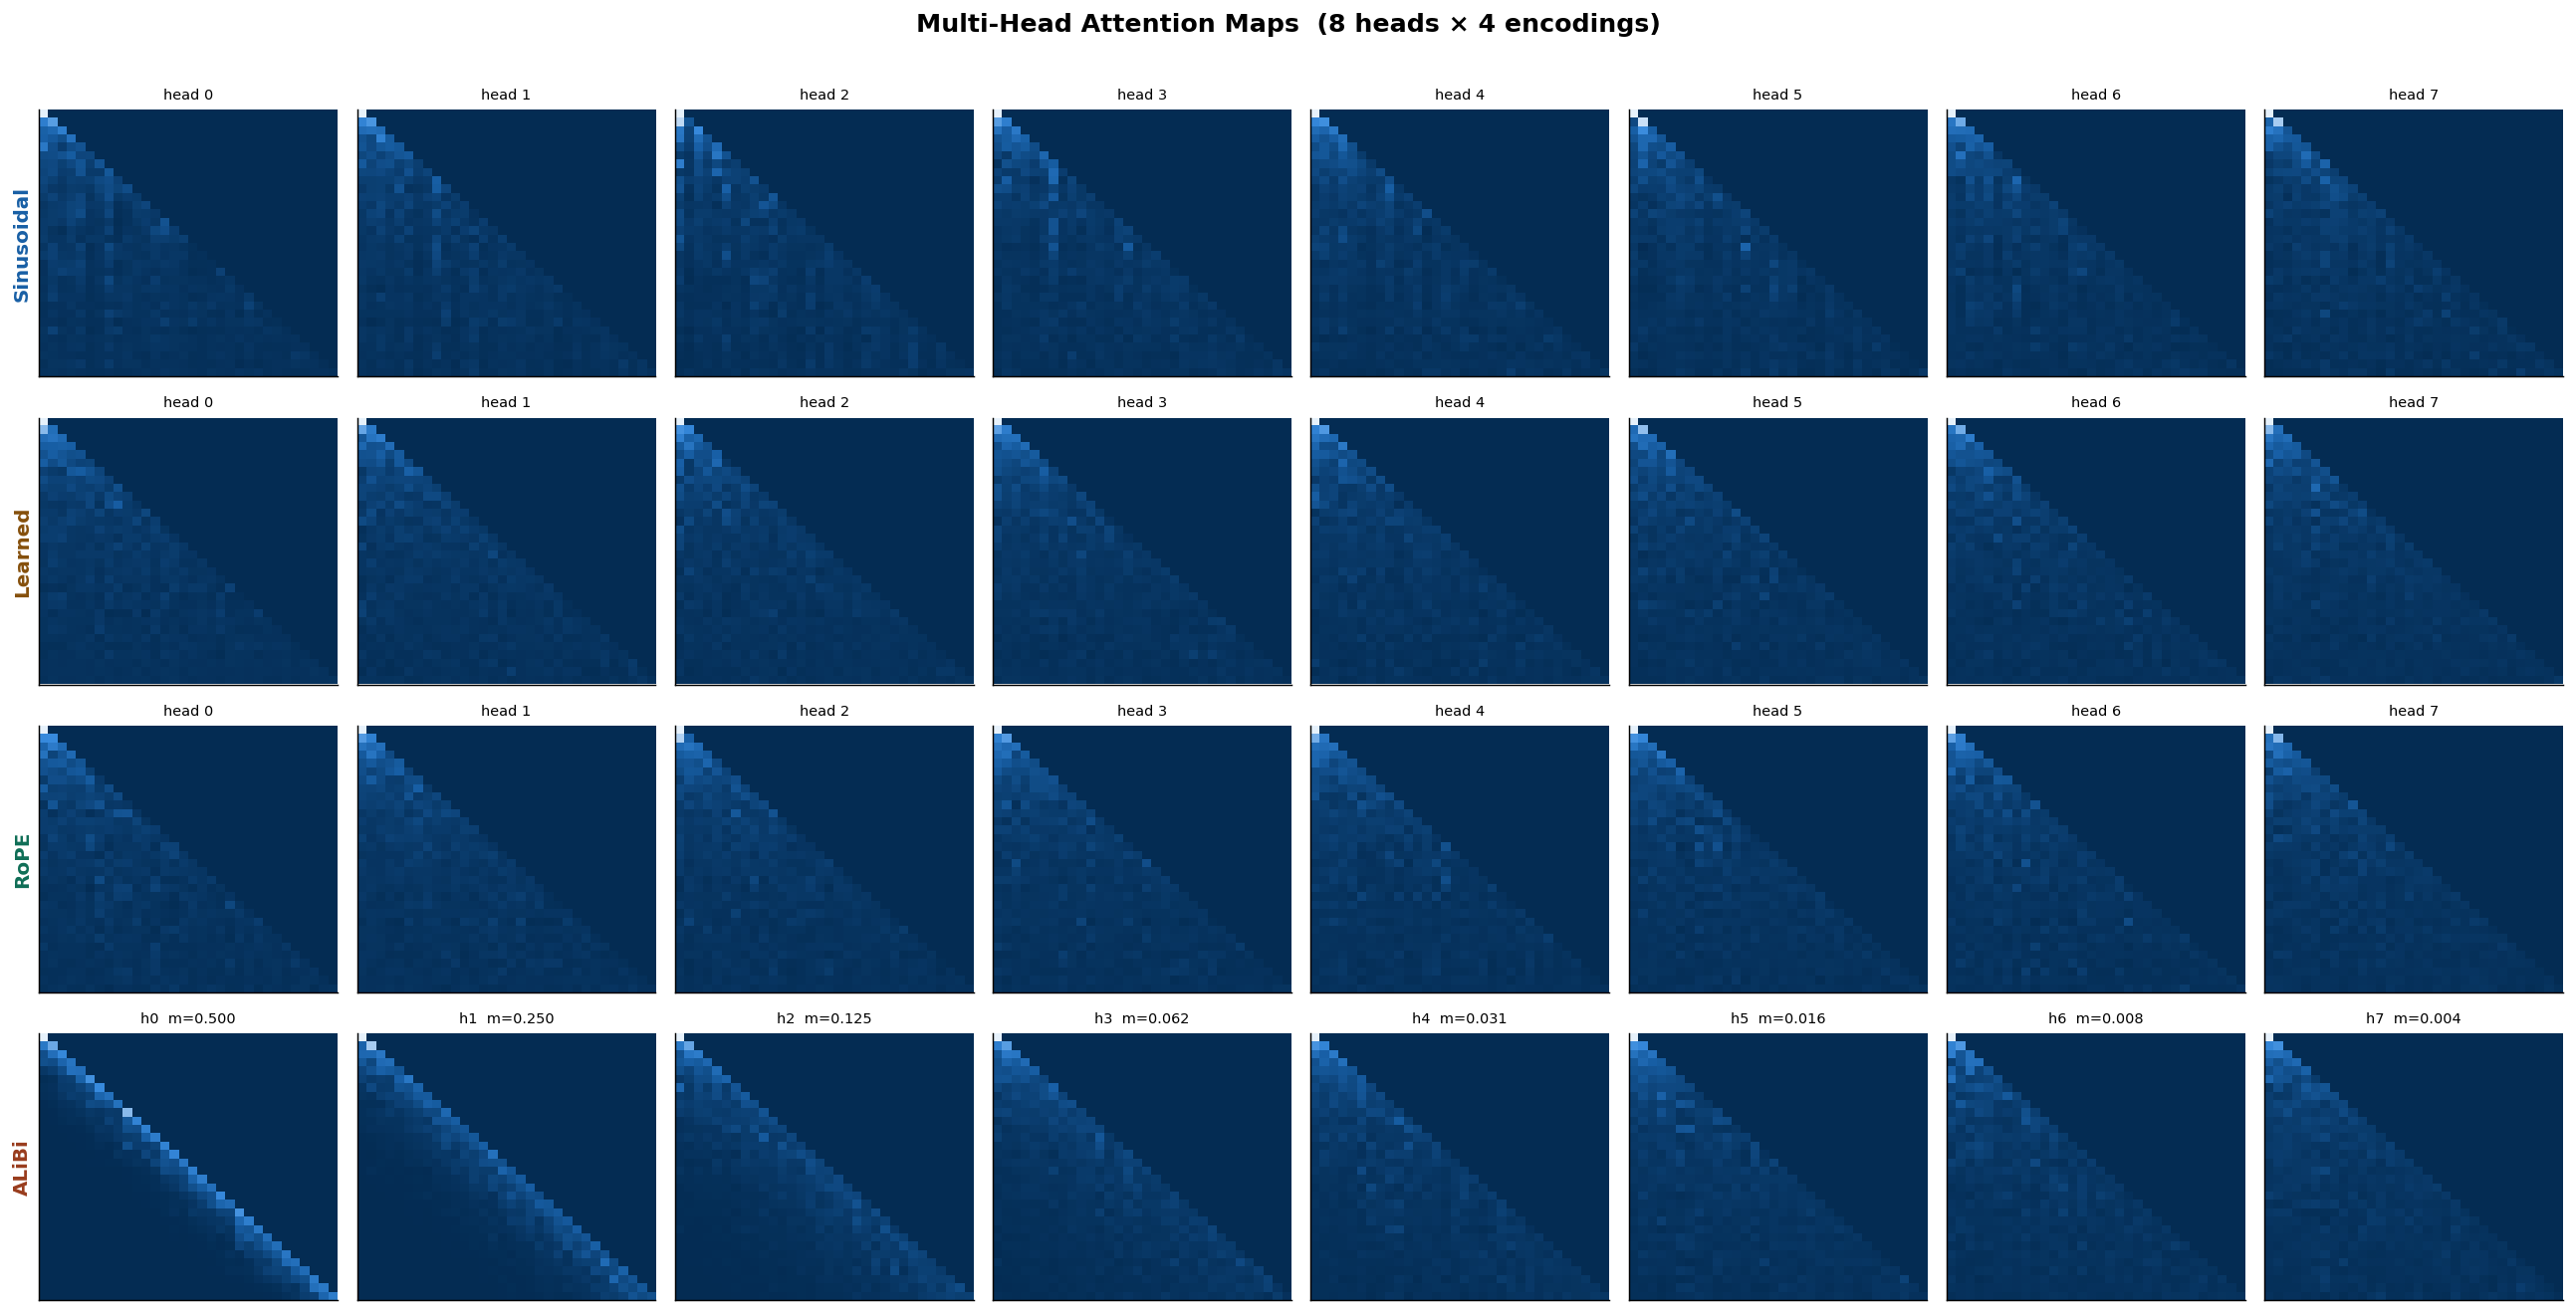

✓ Figure saved → multihead_attention_maps.png


In [13]:
# ── Multi-head attention maps — show all 8 heads for each encoding ────────────
fig, axes = plt.subplots(4, N_HEADS, figsize=(20, 10))
fig.suptitle('Multi-Head Attention Maps  (8 heads × 4 encodings)',
             fontsize=14, fontweight='bold', y=1.01)

enc_labels = ['Sinusoidal', 'Learned', 'RoPE', 'ALiBi']
row_colors = ['#185FA5', '#854F0B', '#0F6E56', '#993C1D']

for row, enc in enumerate(['sinusoidal', 'learned', 'rope', 'alibi']):
    w = multi_weights[enc]   # (H, L, L)
    for h in range(N_HEADS):
        ax = axes[row, h]
        ax.imshow(w[h], aspect='auto', cmap=CMAP_ATTN)
        ax.set_xticks([]); ax.set_yticks([])
        if h == 0:
            ax.set_ylabel(enc_labels[row], fontsize=11,
                          fontweight='bold', color=row_colors[row])
        ax.set_title(f'h{h}  m={slopes_np[h]:.3f}' if enc == 'alibi'
                     else f'head {h}', fontsize=8)

plt.tight_layout()
plt.savefig('multihead_attention_maps.png', bbox_inches='tight')
plt.show()
print('✓ Figure saved → multihead_attention_maps.png')

---
## 7. Extrapolation Analysis

How well does each method handle sequences **longer than training length**?  
We train on length 32 and test on length 64.

In [14]:
TRAIN_LEN = 32
TEST_LEN  = 64    # 2× extrapolation

def extrapolation_score(enc_name: str, train_len: int, test_len: int) -> dict:
    """
    Proxy for extrapolation quality:
    - compute attention entropy on test sequences
    - high entropy = diffuse attention (bad); low = focused (good if diagonal-ish)
    Returns dict with entropy stats.
    """
    torch.manual_seed(1)
    x_long = torch.randn(4, test_len, D_MODEL)   # 4 sequences

    # For learned PE, note that positions > train_len are extrapolated (random init)
    max_len = test_len + 8
    try:
        model = MultiHeadAttnWithPE(D_MODEL, N_HEADS, enc_name, max_len=max_len)
        with torch.no_grad():
            _, w = model(x_long)   # (4, H, L, L)
        # attention entropy per query position
        eps = 1e-9
        ent = -(w * (w + eps).log()).sum(-1)   # (4, H, L)
        return {'mean': ent.mean().item(), 'std': ent.std().item(), 'ok': True}
    except Exception as e:
        return {'mean': float('nan'), 'std': float('nan'), 'ok': False, 'err': str(e)}


print('Extrapolation entropy (lower = more focused attention, proxy for quality)\n')
print(f'{"Encoding":<14} {"Mean entropy":>14} {"Std":>8} {"Status":>10}')
print('-' * 52)
extrap_results = {}
for enc in ['sinusoidal', 'learned', 'rope', 'alibi']:
    r = extrapolation_score(enc, TRAIN_LEN, TEST_LEN)
    extrap_results[enc] = r
    status = 'OK' if r['ok'] else 'ERROR'
    print(f'{enc:<14} {r["mean"]:>14.4f} {r["std"]:>8.4f} {status:>10}')

Extrapolation entropy (lower = more focused attention, proxy for quality)

Encoding         Mean entropy      Std     Status
----------------------------------------------------
sinusoidal             3.1041   0.8837         OK
learned                3.1504   0.8929         OK
rope                   3.1502   0.8925         OK
alibi                  2.7379   0.9133         OK


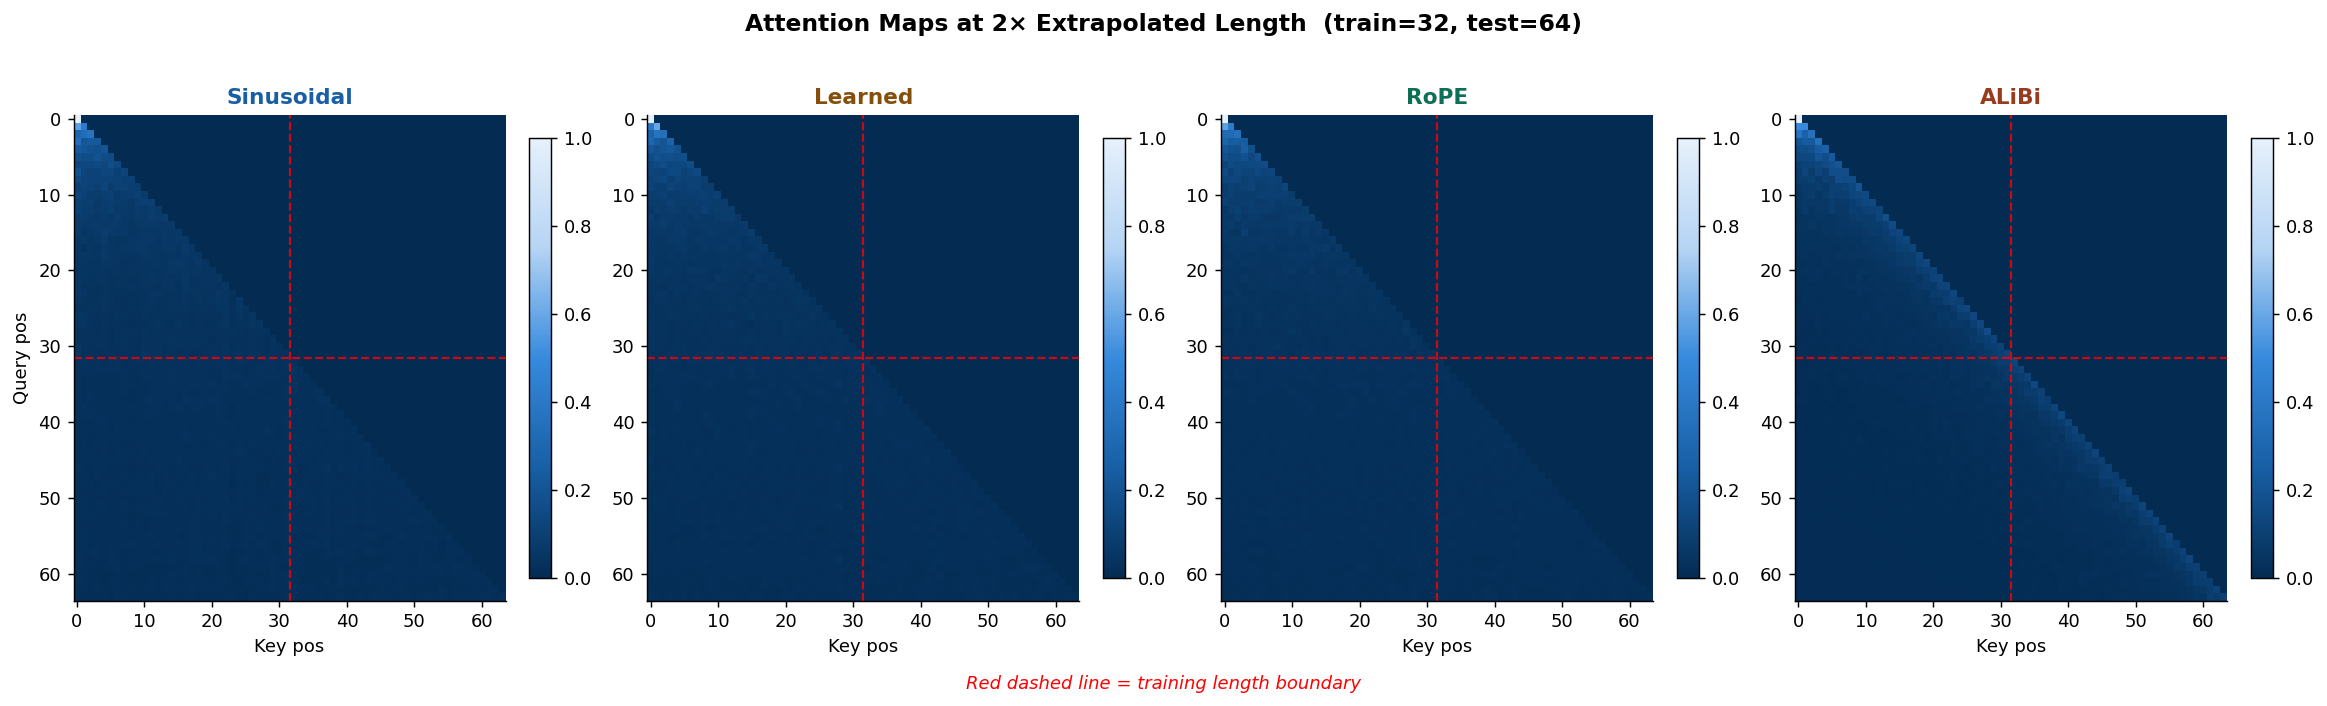

✓ Figure saved → extrapolation_comparison.png


In [15]:
# ── Visualise extrapolation: attention on 2× longer sequence ─────────────────
torch.manual_seed(5)
x_long = torch.randn(1, TEST_LEN, D_MODEL)

fig, axes = plt.subplots(1, 4, figsize=(18, 5))
fig.suptitle(f'Attention Maps at 2× Extrapolated Length  (train={TRAIN_LEN}, test={TEST_LEN})',
             fontsize=13, fontweight='bold', y=1.02)

for col, enc in enumerate(['sinusoidal', 'learned', 'rope', 'alibi']):
    # For learned PE we allow TEST_LEN positions but note positions > TRAIN_LEN are unseen
    ml = TEST_LEN + 8
    model = MultiHeadAttnWithPE(D_MODEL, N_HEADS, enc, max_len=ml)
    with torch.no_grad():
        _, w = model(x_long)
    w_avg = w[0].mean(0).numpy()   # average over heads → (L, L)

    ax = axes[col]
    im = ax.imshow(w_avg, aspect='auto', cmap=CMAP_ATTN)
    ax.set_title(enc_labels[col], fontsize=12, fontweight='bold',
                 color=row_colors[col])
    ax.set_xlabel('Key pos'); ax.axvline(TRAIN_LEN - 0.5, color='red',
                                          linewidth=1.2, linestyle='--', alpha=0.8)
    ax.axhline(TRAIN_LEN - 0.5, color='red', linewidth=1.2, linestyle='--', alpha=0.8)
    if col == 0:
        ax.set_ylabel('Query pos')
    plt.colorbar(im, ax=ax, fraction=0.046)

fig.text(0.5, -0.02, 'Red dashed line = training length boundary', ha='center',
         fontsize=10, color='red', style='italic')
plt.tight_layout()
plt.savefig('extrapolation_comparison.png', bbox_inches='tight')
plt.show()
print('✓ Figure saved → extrapolation_comparison.png')

---
## 8. Summary Dashboard

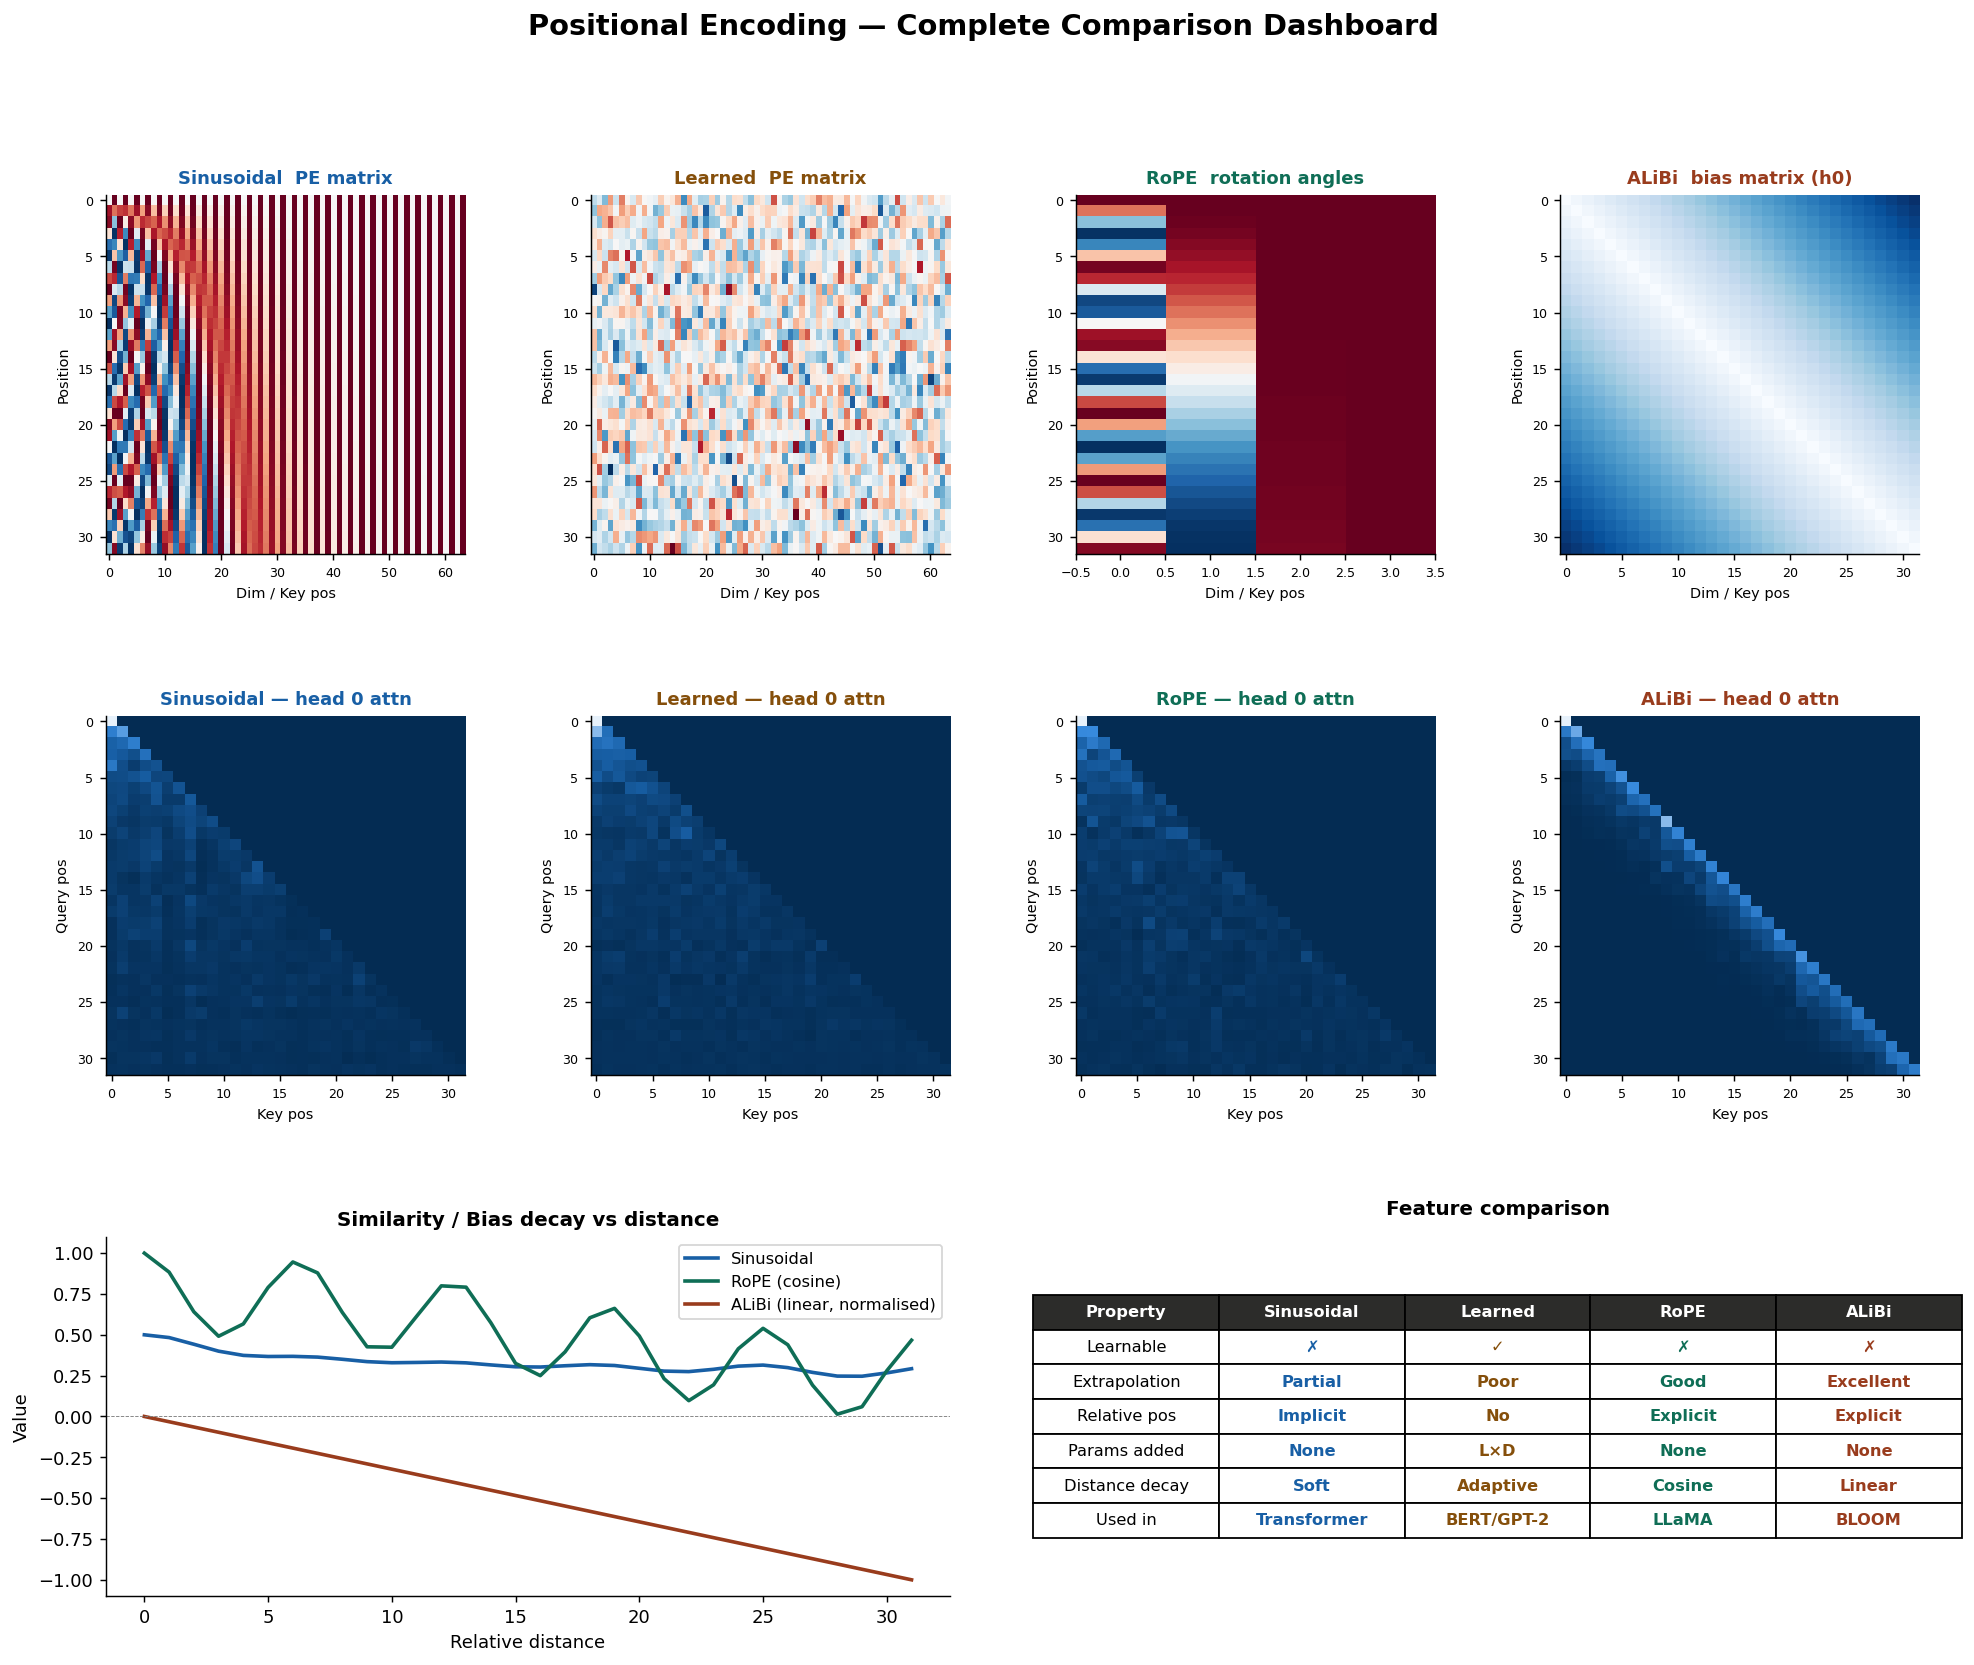

✓ Summary dashboard saved → summary_dashboard.png


In [16]:
fig = plt.figure(figsize=(18, 14))
fig.suptitle('Positional Encoding — Complete Comparison Dashboard',
             fontsize=16, fontweight='bold', y=0.98)

gs = gridspec.GridSpec(3, 4, figure=fig, hspace=0.45, wspace=0.35)

# Row 0: encoding matrices
mats = [sine_mat,
        learned_mat,
        rope.get_rotation_matrix(SEQ_LEN),
        alibi_bias[0]]
row0_titles = ['Sinusoidal  PE matrix',
               'Learned  PE matrix',
               'RoPE  rotation angles',
               'ALiBi  bias matrix (h0)']
cmaps0 = [CMAP_ENC, CMAP_ENC, CMAP_ENC, 'Blues_r']

for col, (mat, title, cmap) in enumerate(zip(mats, row0_titles, cmaps0)):
    ax = fig.add_subplot(gs[0, col])
    ax.imshow(mat, aspect='auto', cmap=cmap)
    ax.set_title(title, fontsize=10, fontweight='bold', color=row_colors[col])
    ax.set_xlabel('Dim / Key pos', fontsize=8)
    ax.set_ylabel('Position', fontsize=8)
    ax.tick_params(labelsize=7)

# Row 1: single-head attention weights
for col, enc in enumerate(['sinusoidal', 'learned', 'rope', 'alibi']):
    w = multi_weights[enc][0]   # head 0
    ax = fig.add_subplot(gs[1, col])
    ax.imshow(w, aspect='auto', cmap=CMAP_ATTN)
    ax.set_title(f'{enc_labels[col]} — head 0 attn', fontsize=10,
                 fontweight='bold', color=row_colors[col])
    ax.set_xlabel('Key pos', fontsize=8); ax.set_ylabel('Query pos', fontsize=8)
    ax.tick_params(labelsize=7)

# Row 2, col 0-1: decay curves
ax = fig.add_subplot(gs[2, :2])
dists = np.arange(SEQ_LEN)
# Sinusoidal: average dot-product decay
sine_decay = np.array([
    (sine_mat[:SEQ_LEN - d] * sine_mat[d:]).sum(1).mean() / D_MODEL
    for d in dists])
# RoPE decay
inv_f = rope.inv_freq.numpy()
rope_decay_arr = np.array([np.mean(np.cos(d * inv_f)) for d in dists])
# ALiBi head 0 decay
alibi_decay = -slopes_np[0] * dists
# Learned: no analytic decay

ax.plot(dists, sine_decay, color=row_colors[0], linewidth=2, label='Sinusoidal')
ax.plot(dists, rope_decay_arr, color=row_colors[2], linewidth=2, label='RoPE (cosine)')
ax.plot(dists, alibi_decay / max(abs(alibi_decay)), color=row_colors[3],
        linewidth=2, label='ALiBi (linear, normalised)')
ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')
ax.set_title('Similarity / Bias decay vs distance', fontsize=11, fontweight='bold')
ax.set_xlabel('Relative distance'); ax.set_ylabel('Value')
ax.legend(fontsize=9)

# Row 2, col 2-3: feature radar / table
ax = fig.add_subplot(gs[2, 2:])
ax.axis('off')
table_data = [
    ['Property', 'Sinusoidal', 'Learned', 'RoPE', 'ALiBi'],
    ['Learnable', '✗', '✓', '✗', '✗'],
    ['Extrapolation', 'Partial', 'Poor', 'Good', 'Excellent'],
    ['Relative pos', 'Implicit', 'No', 'Explicit', 'Explicit'],
    ['Params added', 'None', 'L×D', 'None', 'None'],
    ['Distance decay', 'Soft', 'Adaptive', 'Cosine', 'Linear'],
    ['Used in', 'Transformer', 'BERT/GPT-2', 'LLaMA', 'BLOOM'],
]
tbl = ax.table(cellText=table_data, loc='center', cellLoc='center')
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
tbl.scale(1.1, 1.6)
# style header
for j in range(5):
    tbl[0, j].set_facecolor('#2C2C2A'); tbl[0, j].set_text_props(color='white', fontweight='bold')
# style encoding columns
for row_i in range(1, len(table_data)):
    for col_i, c in enumerate(row_colors):
        tbl[row_i, col_i + 1].set_text_props(color=c, fontweight='bold')
ax.set_title('Feature comparison', fontsize=11, fontweight='bold', pad=12)

plt.savefig('summary_dashboard.png', bbox_inches='tight')
plt.show()
print('✓ Summary dashboard saved → summary_dashboard.png')

---
## 9. Key Takeaways

| | Sinusoidal | Learned | RoPE | ALiBi |
|---|---|---|---|---|
| **Core idea** | Deterministic frequencies | Trainable lookup | Rotate Q/K by angle | Subtract linear bias |
| **Position type** | Absolute | Absolute | Relative (built in) | Relative (built in) |
| **Extra params** | 0 | seq_len × d_model | 0 | 0 |
| **Extrapolation** | Degrades | Fails hard | Good (with NTK/YaRN) | Excellent |
| **Modern use** | Legacy / ViT | BERT, GPT-2 | LLaMA 2/3, Mistral | BLOOM, MPT |
| **Modifies** | Token embed | Token embed | Q, K only | Attention logits |

### Rule of thumb when choosing:
- **Short fixed-length tasks (classification, NLU)** → Learned PE (fully task-adaptive)
- **Long-context generation** → RoPE with NTK scaling (best balance)
- **Ultra-long context without re-training** → ALiBi (zero-shot length generalization)
- **Simplicity / vision transformers** → Sinusoidal or learned 2D PE